<a href="https://colab.research.google.com/github/HofstraDoboli/CSC158_S26/blob/main/atari_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import sys
!{sys.executable} -m pip install gymnasium
!{sys.executable} -m pip install ale-py
!{sys.executable} -m pip install "gymnasium[atari, accept-rom-license]"
!{sys.executable} -m pip install opencv-python

In [14]:
import sys
!{sys.executable} -m pip install autorom[accept-rom-license]

In [2]:
import gymnasium as gym
import numpy as np
import cv2
import random
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [29]:
from ale_py import ALEInterface
ale = ALEInterface()

import ale_py

gym.register_envs(ale_py)
env_ale  = gym.make("ALE/Pong-v5")

obs, info = env_ale.reset()
print(info)
print(env_ale.action_space.sample())
obs, reward, terminated, truncated, info = env_ale.step(env_ale.action_space.sample())
env_ale.close()

print(reward, truncated, info)

{'lives': 0, 'episode_frame_number': 0, 'frame_number': 0}
2
0.0 False {'lives': 0, 'episode_frame_number': 4, 'frame_number': 4}


In [3]:
# =========================
# 1. Environment Wrapper
# =========================
class PongWrapper(gym.Wrapper):
    """
    Handles:
    - Frame skipping (repeat action)
    - Grayscale + resize
    - Frame stacking (gives motion info)
    """
    def __init__(self, env, stack_size = 4): # stack 4 consecutive game frames
        super().__init__(env)
        self.stack_size = stack_size
        self.frames = deque(maxlen = stack_size)

    def preprocess(self, frame):
        # Convert RGB → grayscale
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        # Resize to 84x84
        frame = cv2.resize(frame, (84, 84))

        return frame

    def reset(self):
        obs   = self.env.reset()
        frame = self.preprocess(obs)

        # Fill stack with same frame initially
        self.frames = deque([frame]*self.stack_size, maxlen=self.stack_size)

        return np.stack(self.frames, axis=0)

    def step(self, action):
        total_reward = 0

        # Frame skipping (repeat action 4 times)
        for _ in range(4):
            obs, reward, done, info = self.env.step(action)
            total_reward += reward
            if done:
                break

        frame = self.preprocess(obs)
        self.frames.append(frame)

        return np.stack(self.frames, axis=0), total_reward, done, info


In [28]:
import gymnasium as gym
import numpy as np
import cv2
from collections import deque

# Redefine the PongWrapper class with fixes for gymnasium API compatibility
class PongWrapper(gym.Wrapper):
    """
    Handles:
    - Frame skipping (repeat action)
    - Grayscale + resize
    - Frame stacking (gives motion info)
    """
    def __init__(self, env, stack_size = 4): # stack 4 consecutive game frames
        super().__init__(env)
        self.stack_size = stack_size
        self.frames = deque(maxlen = stack_size)

        # Define observation space for the wrapper as it changes the observation format
        low = np.zeros((stack_size, 84, 84), dtype=np.uint8)
        high = np.ones((stack_size, 84, 84), dtype=np.uint8) * 255
        self.observation_space = gym.spaces.Box(low=low, high=high, dtype=np.uint8)


    def preprocess(self, frame):
        # Convert RGB → grayscale
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        # Resize to 84x84
        frame = cv2.resize(frame, (84, 84))

        return frame

    def reset(self, **kwargs):
        # gym.Env.reset() now returns (observation, info)
        obs, info = self.env.reset(**kwargs) # Corrected: unpack obs and info
        frame = self.preprocess(obs)

        # Fill stack with same frame initially
        self.frames = deque([frame]*self.stack_size, maxlen=self.stack_size)

        return np.stack(self.frames, axis=0), info # Wrapper's reset also returns (obs, info)

    def step(self, action):
        total_reward = 0
        terminated = False
        truncated = False
        info = {}

        # Frame skipping (repeat action 4 times)
        for _ in range(4):
            # gym.Env.step() now returns (observation, reward, terminated, truncated, info)
            obs, reward_step, terminated_step, truncated_step, info_step = self.env.step(action) # Corrected
            total_reward += reward_step
            terminated = terminated or terminated_step
            truncated  = truncated or truncated_step
            info = info_step # Keep the info from the last step

            if terminated or truncated:
                break

        frame = self.preprocess(obs)
        self.frames.append(frame)

        # Wrapper's step method should also return 5 values
        return np.stack(self.frames, axis=0), total_reward, terminated, truncated, info

# Original code from ylEwW6NxlRKt with corrections
env = PongWrapper(gym.make("ALE/Pong-v5"))

num_actions = env.action_space.n
print(num_actions)
init_frame, _ = env.reset() # Corrected: unpack obs and info
print(init_frame.shape) # Corrected: .shape is an attribute, not a method


6
(4, 84, 84)


In [4]:
# =========================
# 2. Replay Buffer
# =========================
class ReplayBuffer:
    """
    Stores past experiences for random sampling
    """
    def __init__(self, capacity=100000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s_next, done):
        self.buffer.append((s, a, r, s_next, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, s_next, d = zip(*batch)

        return (
            torch.tensor(s, dtype=torch.float32),
            torch.tensor(a),
            torch.tensor(r, dtype=torch.float32),
            torch.tensor(s_next, dtype=torch.float32),
            torch.tensor(d, dtype=torch.float32),
        )

    def __len__(self):
        return len(self.buffer)



In [5]:
# =========================
# 3. Neural Network
# =========================
class DQN(nn.Module):
    """
    Convolutional network for image input (Atari-style)
    Input: (4, 84, 84)
    Output: Q-values for each action
    """
    def __init__(self, num_actions):
        super().__init__()

        # input image number of channels = 4
        # number of kernels = 32
        #  kernel_size = 8 X 8
        #  stride = 4
        self.conv1 = nn.Conv2d(4, 32, kernel_size = 8, stride = 4)
        # output 32 X 21 X 21
        # conv2: 32 input channels, 64 kernels, kernel size 4X4 stride of 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size = 4, stride = 2)
        # output conv2 =  64 X 10 X 10
        # conv3 = 64 input channels, 64 fileters, 3 X 3 kernel size, stride = 1
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, stride = 1)
        # output conv3 = 64 X 7 X 7
        self.fc1 = nn.Linear(7*7*64, 512)
        self.fc2 = nn.Linear(512, num_actions)

    def forward(self, x):
        x = x / 255.0  # normalize pixels

        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))

        x = x.view(x.size(0), -1) # flatten the layer

        x = F.relu(self.fc1(x)) # relu to the first linear linear
        return self.fc2(x)



In [18]:
# =========================
# 4. Setup
# =========================
env = PongWrapper(gym.make("ALE/Pong-v5"))

num_actions = env.action_space.n
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

q_net = DQN(num_actions).to(device)
target_net = DQN(num_actions).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-4)
buffer = ReplayBuffer()

# Hyperparameters
gamma = 0.99
batch_size = 32
epsilon = 1.0
epsilon_min = 0.1
epsilon_decay = 1e-6
target_update_freq = 10000
train_start = 5000

step_count = 0

KeyboardInterrupt: 

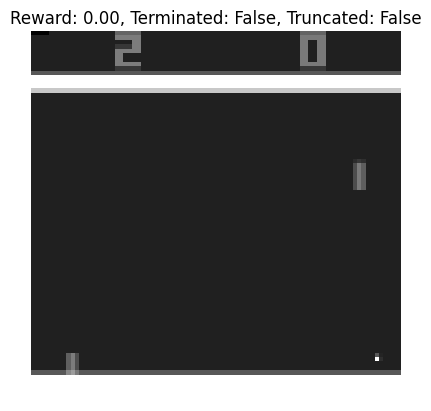

In [30]:
import matplotlib.pyplot as plt
from IPython import display

# Create a fresh environment for visualization
env_viz = PongWrapper(gym.make("ALE/Pong-v5", render_mode="rgb_array"))

obs, info = env_viz.reset()

for _ in range(100): # Run for 100 steps to see some game play
    action = env_viz.action_space.sample() # Take a random action
    obs, reward, terminated, truncated, info = env_viz.step(action)

    # The observation is already a stack of 4 frames. Let's display the last one.
    # The obs shape is (stack_size, 84, 84), so we take the last frame: obs[-1]
    plt.imshow(obs[-1], cmap='gray')
    plt.title(f"Reward: {reward:.2f}, Terminated: {terminated}, Truncated: {truncated}")
    plt.axis('off')
    display.display(plt.gcf())
    display.clear_output(wait=True)

    if terminated or truncated:
        break

env_viz.close()
print("Game visualization finished.")